## Project: Mapping the Potential Destructive Power of Wildfires Using Machine Learning

### Module 2: *Variable Selection*

---
### Contents  
- 2. Independent Variables Analysis
---
### Notes
---
### Inputs
- `merged_weather_fire` cleaned weather data joined with cleaned fire damage dataset
---
### Outputs 
- `trimmmed_merged_weather_fire` - for future modeling
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

# Function to create all second degree interactions possible in a dataset, then name these terms
# in the format of feature1_x_feature2. Returns dataframe of interactions.
from src.data_utils import create_2nd_degree_interactions

# A space saving function to rank interactions
from src.data_utils import rank_interactions_by_correlation

# Function to calculate dryness index and return a dataframe
from src.data_utils import calculate_dryness_index

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

# Modeling prep
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

## 2. Feature Exploration and Selection

This section visualizes key environmental variables to assess their relationships with wildfire severity categories. Based on the `Categorical Index`, we explore how different weather features interact and influence fire risk.

### 2.1 Load variables

In [3]:
# Copy details for use later in the project
final_details = pd.read_csv("../data/processed/final_details.csv")

# create a new dataframe with only independent variables and target index for analysis
filtered = pd.read_csv("../data/processed/Raw_X.csv")
filtered['Target'] = pd.read_csv("../data/processed/Raw_y.csv")

In [4]:
filtered

,Unnamed: 0,Fire Name,Start,Lat,Lon,Stn Id,station_dist,Avg Air Temp (F),Max Air Temp (F),Min Air Temp (F),...,Wind Run (miles),Precip (in),Dew Point (F),Avg Vap Pres (mBars),Sol Rad (Ly/day),ETo (in),Total Population,density,Mean Income,Target
0,0,46th,2019-10-31,33.973814,-117.430053,44,0.093492,65.614286,79.228571,51.628571,...,118.142857,0.00,161.2,4.642857,429.428571,1.13,2492442,345.861225,93563,1
1,1,Aborn,2019-07-15,37.320320,-121.754095,191,0.367749,67.485714,83.557143,54.142857,...,96.428571,0.00,381.7,14.542857,709.714286,1.72,1877592,1455.384854,174331,0
2,2,Aero,2024-06-17,37.992816,-120.661811,194,0.332019,72.500000,89.300000,55.342857,...,110.328571,0.00,406.7,16.857143,701.857143,1.83,46565,45.651513,84164,1
3,4,Airport,2024-09-09,33.656392,-117.443056,245,0.146400,82.185714,101.500000,65.842857,...,31.500000,0.00,437.9,19.385714,535.571429,1.39,3135755,3966.448259,127056,2
4,5,Alisal,2021-10-11,34.505960,-120.083681,64,0.077311,61.742857,82.085714,47.185714,...,70.057143,0.13,353.0,12.671429,408.571429,0.92,441257,161.331803,111731,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,221,Willow,2020-09-01,39.376113,-121.326385,84,0.124016,78.271429,91.342857,64.471429,...,74.657143,0.00,391.7,15.285714,477.285714,1.39,85722,135.670423,73030,2
196,222,Winding,2022-07-18,39.319278,-121.276206,84,0.077515,83.471429,97.442857,68.085714,...,97.314286,0.00,347.6,12.171429,715.571429,2.11,85722,135.670423,73030,1
197,224,Woods,2022-09-01,37.969815,-120.400392,194,0.515830,73.600000,90.785714,58.857143,...,115.185714,0.00,415.2,17.271429,566.285714,1.50,54204,24.406542,83401,0
198,225,Woolsey,2018-11-08,34.077969,-118.818547,217,0.193524,66.228571,81.857143,54.500000,...,89.871429,0.00,311.5,10.542857,320.571429,0.88,9663345,2381.377714,103220,2


> ### Note  
> To reduce dataset size and simplify analysis, the following steps were taken:  
> - Dropped **Min** and **Max Air Temperature**, retained **Average Air Temperature**  
> - Dropped **Min** and **Max Relative Humidity**, retained **Average Relative Humidity**

In [5]:
drop = ['Max Air Temp (F)','Min Air Temp (F)','Max Rel Hum (%)','Min Rel Hum (%)']

### 4.2 DIrect Water Demand Indicators

- `ETo (in)` - Evapotranspiration is a measure of how much water is lost to the atmosphere
- `Sol Rad (Ly/day)` - A measure of sunlight the soil has recieved in a day
- `Avg Air Temp (F)`- Elevated air temperatures increase vegetation dryness and boost fire intensity  
- `Avg Wind Speed (mph)` - Stronger winds accelerate fire spread and push embers further, creating spot fires 
- `Avg Soil Temp (F)` - Warm soils suggest extended dry periods; contribute to desiccated fuel beds  
- `Wind Run (miles)` - Total wind movement over time; influences how far and fast fires can travel

In [6]:
filtered

,Unnamed: 0,Fire Name,Start,Lat,Lon,Stn Id,station_dist,Avg Air Temp (F),Max Air Temp (F),Min Air Temp (F),...,Wind Run (miles),Precip (in),Dew Point (F),Avg Vap Pres (mBars),Sol Rad (Ly/day),ETo (in),Total Population,density,Mean Income,Target
0,0,46th,2019-10-31,33.973814,-117.430053,44,0.093492,65.614286,79.228571,51.628571,...,118.142857,0.00,161.2,4.642857,429.428571,1.13,2492442,345.861225,93563,1
1,1,Aborn,2019-07-15,37.320320,-121.754095,191,0.367749,67.485714,83.557143,54.142857,...,96.428571,0.00,381.7,14.542857,709.714286,1.72,1877592,1455.384854,174331,0
2,2,Aero,2024-06-17,37.992816,-120.661811,194,0.332019,72.500000,89.300000,55.342857,...,110.328571,0.00,406.7,16.857143,701.857143,1.83,46565,45.651513,84164,1
3,4,Airport,2024-09-09,33.656392,-117.443056,245,0.146400,82.185714,101.500000,65.842857,...,31.500000,0.00,437.9,19.385714,535.571429,1.39,3135755,3966.448259,127056,2
4,5,Alisal,2021-10-11,34.505960,-120.083681,64,0.077311,61.742857,82.085714,47.185714,...,70.057143,0.13,353.0,12.671429,408.571429,0.92,441257,161.331803,111731,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,221,Willow,2020-09-01,39.376113,-121.326385,84,0.124016,78.271429,91.342857,64.471429,...,74.657143,0.00,391.7,15.285714,477.285714,1.39,85722,135.670423,73030,2
196,222,Winding,2022-07-18,39.319278,-121.276206,84,0.077515,83.471429,97.442857,68.085714,...,97.314286,0.00,347.6,12.171429,715.571429,2.11,85722,135.670423,73030,1
197,224,Woods,2022-09-01,37.969815,-120.400392,194,0.515830,73.600000,90.785714,58.857143,...,115.185714,0.00,415.2,17.271429,566.285714,1.50,54204,24.406542,83401,0
198,225,Woolsey,2018-11-08,34.077969,-118.818547,217,0.193524,66.228571,81.857143,54.500000,...,89.871429,0.00,311.5,10.542857,320.571429,0.88,9663345,2381.377714,103220,2


In [7]:
water_demand = ['ETo (in)', 'Sol Rad (Ly/day)', 'Avg Air Temp (F)', 'Avg Wind Speed (mph)', 
                'Avg Soil Temp (F)','Wind Run (miles)','Target']

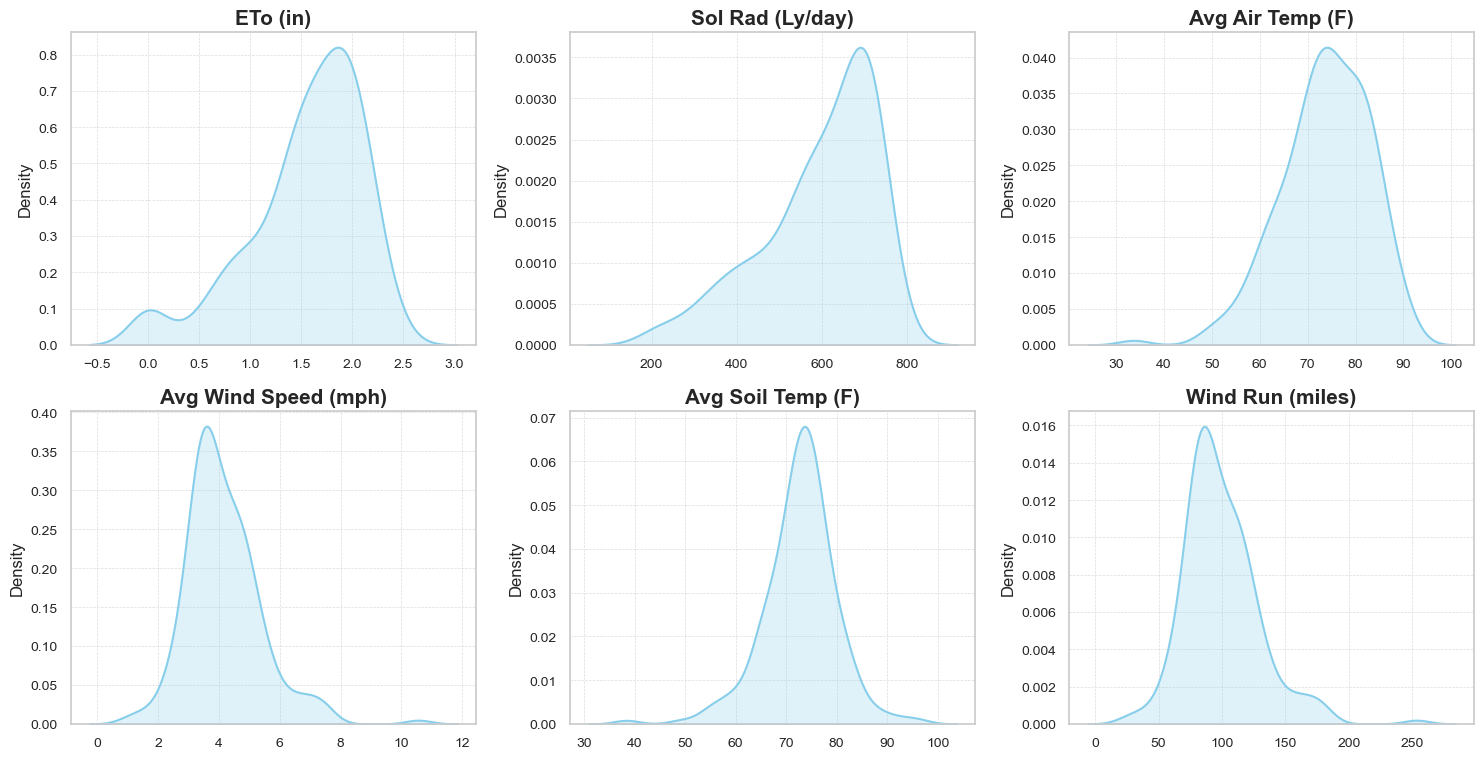

In [8]:
grid_kde(filtered[water_demand].drop(columns='Target'))

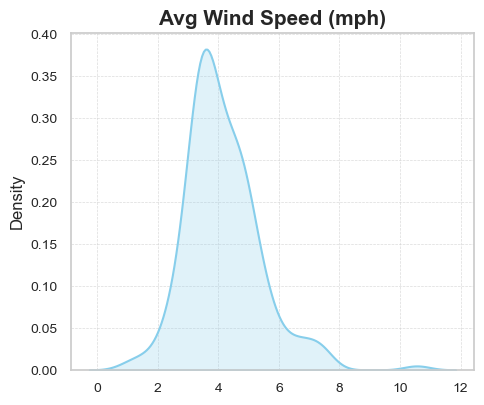

In [9]:
filtered['Avg Wind Speed (mph)'] = filtered['Avg Wind Speed (mph)'].clip(upper=400)

grid_kde(filtered[['Avg Wind Speed (mph)']])

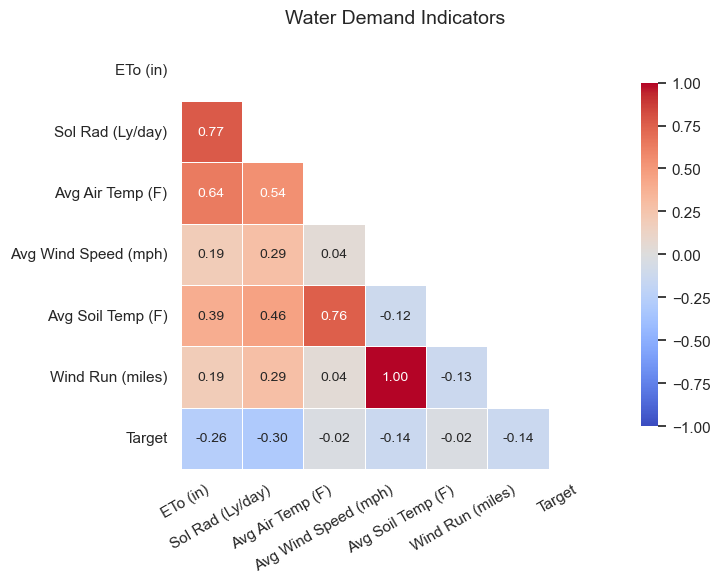

In [10]:
correlation_map(filtered[water_demand],'Water Demand Indicators')

#### Key Insights: Water Demand Variables

- **Evapotranspiration (ETo)** and **Solar Radiation** show a strong positive correlation, indicating shared influence from sunlight and temperature — both crucial in assessing vegetation moisture loss.
  
- **Dew Point** and **Vapor Pressure** are highly correlated, suggesting they provide overlapping information. These variables reflect atmospheric moisture content and may be redundant in modeling.

- Together, these indicators are effective in representing **vegetation dryness**, a critical factor in estimating wildfire ignition and spread potential.

- `ETO` and `Avg Vapor Pressure` are more correllated with target


#### Colinearity examination

sns.scatterplot(
    x='ETo (in)', y='Sol Rad (Ly/day)', hue='Adjusted Value', data=filtered, palette='viridis', alpha=0.7
)

#### Water Demand Indicators - Key Findings

- **Evapotranspiration (ETo)** and **Solar Radiation** showed a **strong positive correlation**, indicating that days with high solar energy also tend to have greater evaporative demand. This aligns with meteorological understanding and highlights both as valuable indicators of fuel dryness.

<Axes: xlabel='Avg Wind Speed (mph)', ylabel='Wind Run (miles)'>

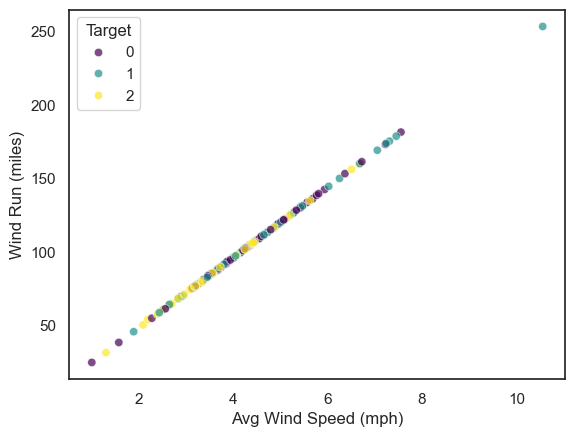

In [11]:
sns.scatterplot(
    x='Avg Wind Speed (mph)', y='Wind Run (miles)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

<Axes: xlabel='Avg Soil Temp (F)', ylabel='Avg Air Temp (F)'>

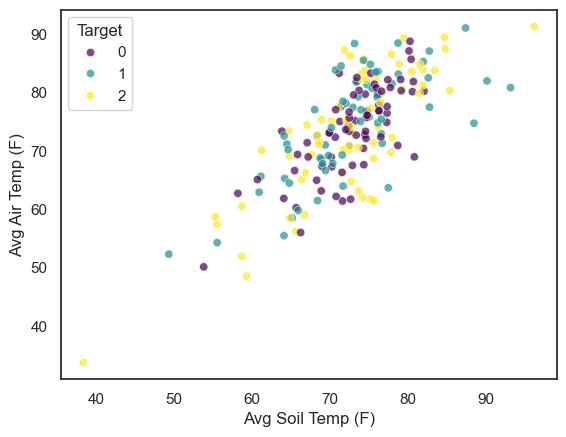

In [12]:
sns.scatterplot(
    x='Avg Soil Temp (F)', y='Avg Air Temp (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

In [13]:
drop.extend(['Wind Run (miles)'])
drop

['Max Air Temp (F)',
 'Min Air Temp (F)',
 'Max Rel Hum (%)',
 'Min Rel Hum (%)',
 'Wind Run (miles)']

### 4.3 Water Supply Indicators

- `Precip (in)` - Rainfall reduces wildfire risk by moistening vegetation and fuels; prolonged dryness increases flammability
- `Avg Rel Hum (%)` - Average relative humidity reflects how saturated the air is; lower values dry out fuels and promote ignition
- `Avg Vap Pres (mBars)` - Vapor pressure indicates moisture content in the air; lower pressure signals drier conditions favorable for fire spread  
- `Dew Point (F)` - The temperature at which air becomes saturated; lower dew points mean drier air, increasing fire potential 

In [14]:
water_supply = ['Precip (in)', 'Avg Rel Hum (%)', 'Avg Vap Pres (mBars)', 'Dew Point (F)', 'Target']

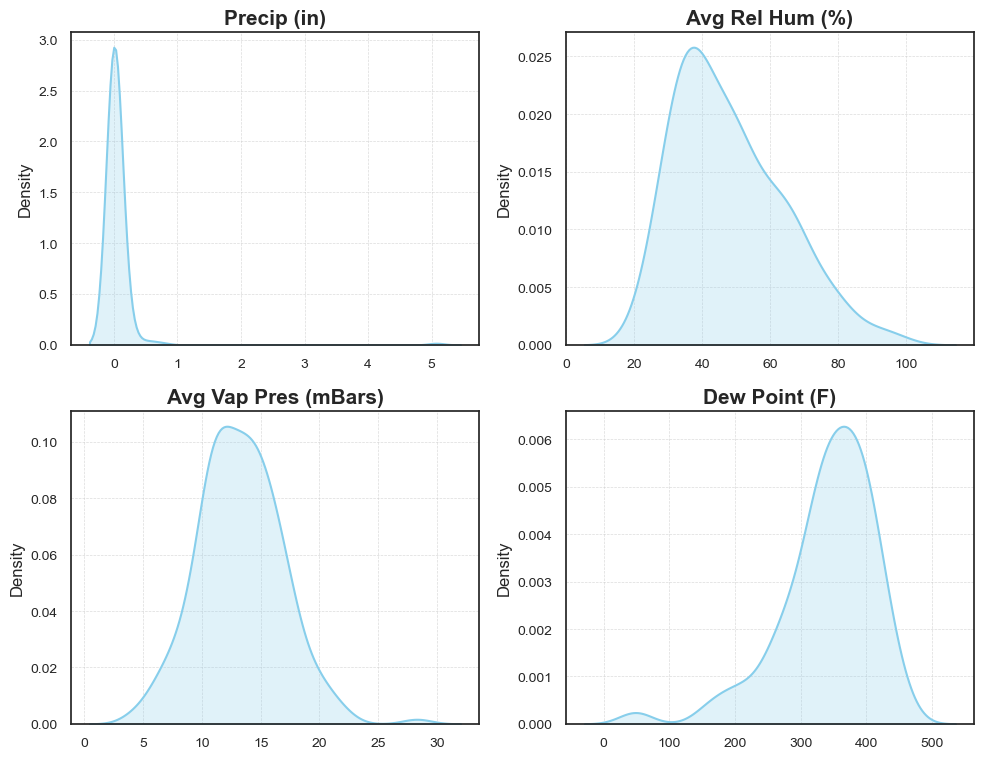

In [15]:
grid_kde(filtered[water_supply].drop(columns='Target'))

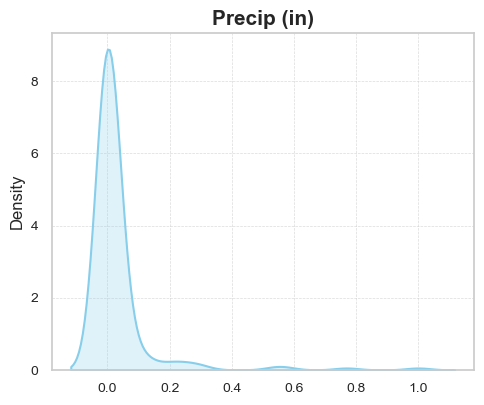

In [16]:
filtered['Precip (in)'] = filtered['Precip (in)'].clip(upper=1)

grid_kde(filtered[['Precip (in)']])

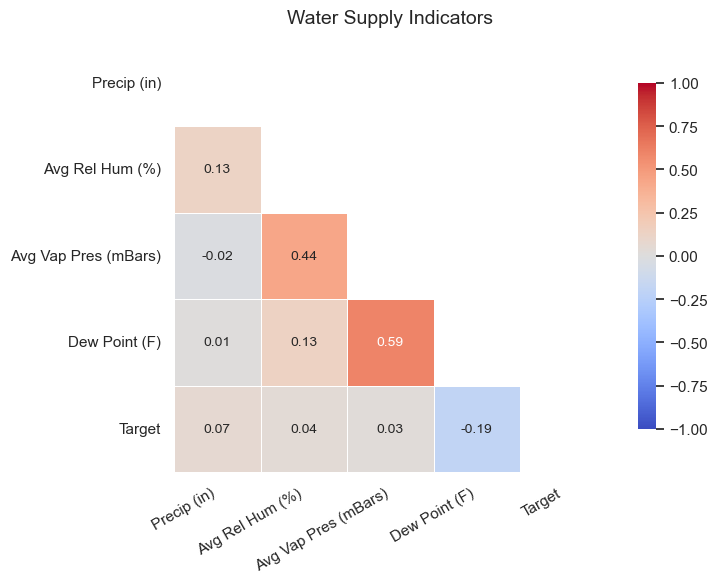

In [17]:
correlation_map(filtered[water_supply],'Water Supply Indicators')

#### Water Supply Indicators – Key Insights

- **Inverse Relationship with Fire Severity**  
  Both precipitation and relative humidity indicators are **negatively correlated** with the categorical fire risk index. This aligns with domain expectations—**drier and less humid conditions correspond to higher wildfire severity**.

<Axes: xlabel='Avg Vap Pres (mBars)', ylabel='Dew Point (F)'>

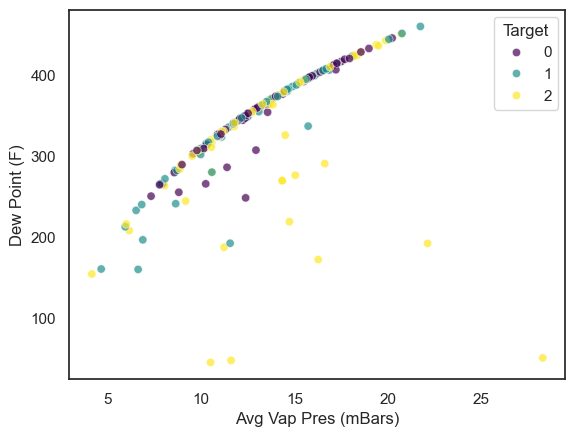

In [18]:
sns.scatterplot(
    x='Avg Vap Pres (mBars)', y='Dew Point (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

Drop `Dew Point (F)` due to **colinearity** with `Avg Vap Pres (mBars)` and less correlation with the target index

In [19]:
drop.extend(['Dew Point (F)'])
drop

['Max Air Temp (F)',
 'Min Air Temp (F)',
 'Max Rel Hum (%)',
 'Min Rel Hum (%)',
 'Wind Run (miles)',
 'Dew Point (F)']

In [20]:
selected = filtered.drop(columns = drop)
selected

,Unnamed: 0,Fire Name,Start,Lat,Lon,Stn Id,station_dist,Avg Air Temp (F),Avg Rel Hum (%),Avg Wind Speed (mph),Avg Soil Temp (F),Precip (in),Avg Vap Pres (mBars),Sol Rad (Ly/day),ETo (in),Total Population,density,Mean Income,Target
0,0,46th,2019-10-31,33.973814,-117.430053,44,0.093492,65.614286,22.857143,4.914286,61.142857,0.00,4.642857,429.428571,1.13,2492442,345.861225,93563,1
1,1,Aborn,2019-07-15,37.320320,-121.754095,191,0.367749,67.485714,63.571429,4.028571,72.885714,0.00,14.542857,709.714286,1.72,1877592,1455.384854,174331,0
2,2,Aero,2024-06-17,37.992816,-120.661811,194,0.332019,72.500000,60.714286,4.614286,68.342857,0.00,16.857143,701.857143,1.83,46565,45.651513,84164,1
3,4,Airport,2024-09-09,33.656392,-117.443056,245,0.146400,82.185714,52.857143,1.314286,75.828571,0.00,19.385714,535.571429,1.39,3135755,3966.448259,127056,2
4,5,Alisal,2021-10-11,34.505960,-120.083681,64,0.077311,61.742857,67.857143,2.928571,75.157143,0.13,12.671429,408.571429,0.92,441257,161.331803,111731,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,221,Willow,2020-09-01,39.376113,-121.326385,84,0.124016,78.271429,46.285714,3.100000,76.442857,0.00,15.285714,477.285714,1.39,85722,135.670423,73030,2
196,222,Winding,2022-07-18,39.319278,-121.276206,84,0.077515,83.471429,31.285714,4.057143,75.885714,0.00,12.171429,715.571429,2.11,85722,135.670423,73030,1
197,224,Woods,2022-09-01,37.969815,-120.400392,194,0.515830,73.600000,61.000000,4.800000,72.042857,0.00,17.271429,566.285714,1.50,54204,24.406542,83401,0
198,225,Woolsey,2018-11-08,34.077969,-118.818547,217,0.193524,66.228571,52.000000,3.728571,66.857143,0.00,10.542857,320.571429,0.88,9663345,2381.377714,103220,2


In [23]:
y = selected['Target']
X = selected.drop(columns=['Unnamed: 0','Fire Name','Start','Lat','Lon','Stn Id','station_dist','Target'])

In [25]:
X.to_csv('../data/processed/X.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)